In [2]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

packages = [
    'transformers>=4.45.0',
    'peft>=0.12.0',
    'bitsandbytes>=0.43.0',
    'accelerate>=0.34.0',
    'trl>=0.11.0',
    'qwen-vl-utils',
    'torchvision',
    'datasets',
    'gradio',
    'Pillow',
    'rouge-score',
    'matplotlib',
    'pandas',
]

for pkg in packages:
    try:
        install(pkg)
        print(f' {pkg}')
    except Exception as e:
        print(f'  {pkg}: {e}')

print('\n All packages installed.')

 transformers>=4.45.0
 peft>=0.12.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.9 MB/s eta 0:00:00
 bitsandbytes>=0.43.0
 accelerate>=0.34.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 17.8 MB/s eta 0:00:00
 trl>=0.11.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 59.9 MB/s eta 0:00:00
 qwen-vl-utils
 torchvision
 datasets
 gradio
 Pillow
 rouge-score
 matplotlib
 pandas

 All packages installed.


In [4]:
import os, gc, json, math, random, shutil, warnings, time
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoTokenizer,
    AutoProcessor,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    get_cosine_schedule_with_warmup,
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    TaskType,
    PeftModel,
)
from trl import SFTTrainer, SFTConfig
from datasets import Dataset as HFDataset
from qwen_vl_utils import process_vision_info

CFG = {
    # Paths
    'dataset_path'   : '/kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508',
    'output_dir'     : '/kaggle/working/qlora_checkpoints',
    'final_model_dir': '/kaggle/working/final_model',
    'log_file'       : '/kaggle/working/training_log.json',

    # Model
    'model_name'     : 'Qwen/Qwen2-VL-2B-Instruct',

    # Image
    'img_size'       : 512,           
    'max_pixels'     : 512 * 512,
    'min_pixels'     : 256 * 256,

    # LoRA
    'lora_r'         : 16,
    'lora_alpha'     : 32,
    'lora_dropout'   : 0.05,

    # Training
    'epochs'         : 2,
    'batch_size'     : 1,
    'grad_accum'     : 4,
    'lr'             : 1.5e-4,
    'max_seq_len'    : 1024,
    'train_ratio'    : 0.8,
    'max_samples'    : 3000, 
    'min_samples'    : 2000,   
    'auto_adjust'    : True,  
    # Reproducibility
    'seed'           : 42,
    'bf16'           : False,         # T4 does NOT support bf16
    'fp16'           : True,
}

# Seed everything
random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])

# Directories
Path(CFG['output_dir']).mkdir(parents=True, exist_ok=True)
Path(CFG['final_model_dir']).mkdir(parents=True, exist_ok=True)

# Device info
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    n_gpus = torch.cuda.device_count()
    for i in range(n_gpus):
        p = torch.cuda.get_device_properties(i)
        print(f'  GPU {i}: {p.name}  VRAM={p.total_memory/1e9:.1f} GB')
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'
print('Device:', DEVICE)

PyTorch: 2.10.0+cu128
CUDA available: True
  GPU 0: Tesla T4  VRAM=15.6 GB
  GPU 1: Tesla T4  VRAM=15.6 GB
Device: cuda


In [7]:
def free_memory():
    """Aggressively free GPU/CPU memory."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def mem_stats(label=''):
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        print(f'[{label}] GPU mem  allocated={alloc:.2f} GB  reserved={reserved:.2f} GB')

def save_checkpoint_meta(epoch, step, train_loss, val_loss=None):
    """Save lightweight JSON meta so we can detect + resume after kernel restart."""
    meta = {
        'epoch'     : epoch,
        'step'      : step,
        'train_loss': train_loss,
        'val_loss'  : val_loss,
        'timestamp' : datetime.now().isoformat(),
    }
    with open(CFG['log_file'], 'w') as f:
        json.dump(meta, f, indent=2)
    print(f'  Meta saved → {CFG["log_file"]}')

def load_checkpoint_meta():
    if os.path.exists(CFG['log_file']):
        with open(CFG['log_file']) as f:
            return json.load(f)
    return None

def find_latest_checkpoint(output_dir):
    """Return path to the most recent Trainer checkpoint folder, or None."""
    ckpts = sorted(
        [d for d in Path(output_dir).glob('checkpoint-*') if d.is_dir()],
        key=lambda p: int(p.name.split('-')[-1])
    )
    return str(ckpts[-1]) if ckpts else None

# Check for prior run
prior = load_checkpoint_meta()
latest_ckpt = find_latest_checkpoint(CFG['output_dir'])
if prior:
    print(f' Prior run detected: epoch={prior["epoch"]}  step={prior["step"]}  loss={prior["train_loss"]}')
    if latest_ckpt:
        print(f'   Resumable checkpoint: {latest_ckpt}')
    else:
        print('   No checkpoint folder found — will start fresh.')
else:
    print('No prior run detected. Starting fresh.')

No prior run detected. Starting fresh.


In [8]:
DATASET_PATH = Path(CFG['dataset_path'])

# ── discover available files ──────────────────────────────────
print('Dataset root:', DATASET_PATH)
all_files = list(DATASET_PATH.rglob('*'))
print(f'Total files: {len(all_files)}')

# summarise by extension
from collections import Counter
ext_counts = Counter(f.suffix.lower() for f in all_files if f.is_file())
for ext, cnt in ext_counts.most_common(10):
    print(f'  {ext or "(no ext)"}  →  {cnt} files')

# ── load image–markdown pairs ─────────────────────────────────
def discover_pairs(root: Path):
    """Find (image_path, md_path) pairs. Handles flat and nested layouts."""
    img_exts  = {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.webp'}
    md_exts   = {'.md', '.mmd', '.txt'}
    pairs     = []

    # Strategy 1: every image has a sibling md/mmd/txt with same stem
    img_files = [f for f in root.rglob('*') if f.suffix.lower() in img_exts]
    for img in img_files:
        for ext in md_exts:
            target = img.with_suffix(ext)
            if target.exists():
                pairs.append((str(img), str(target)))
                break

    if pairs:
        return pairs

    # Strategy 2: separate images/ and targets/ directories
    img_dir = root / 'images'
    tgt_dir = root / 'targets'
    if img_dir.exists() and tgt_dir.exists():
        for img in sorted(img_dir.rglob('*')):
            if img.suffix.lower() not in img_exts:
                continue
            for ext in md_exts:
                tgt = tgt_dir / img.relative_to(img_dir).with_suffix(ext)
                if tgt.exists():
                    pairs.append((str(img), str(tgt)))
                    break

    # Strategy 3: JSON manifest
    for json_path in root.rglob('*.json'):
        try:
            data = json.loads(json_path.read_text())
            if isinstance(data, list) and data and 'image' in data[0]:
                for item in data:
                    img_p = root / item['image']
                    md_text = item.get('markdown') or item.get('text') or item.get('label', '')
                    if img_p.exists() and md_text:
                        pairs.append((str(img_p), md_text))  # md_text inline
        except Exception:
            pass

    return pairs

raw_pairs = discover_pairs(DATASET_PATH)
# =========================
# DATASET CONTROL (NEW)
# =========================

print(f'\nDiscovered {len(raw_pairs)} image-markdown pairs.')

# Shuffle dataset
random.shuffle(raw_pairs)

# Apply max_samples cap
if CFG['max_samples'] is not None:
    original_size = len(raw_pairs)
    raw_pairs = raw_pairs[:CFG['max_samples']]
    print(f'Using subset: {len(raw_pairs)} / {original_size} samples')

# Safety check
if len(raw_pairs) < CFG['min_samples']:
    print(f'Warning: dataset is small ({len(raw_pairs)} samples)')
# =========================


if CFG.get('auto_adjust', False):
    n = len(raw_pairs)

    if n > 6000:
        CFG['epochs'] = 2
    elif n > 4000:
        CFG['epochs'] = min(CFG['epochs'], 3)
    else:
        CFG['epochs'] = min(CFG['epochs'], 4)

    print(f'Auto-adjusted epochs → {CFG["epochs"]}')


Dataset root: /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508
Total files: 32932
  .png  →  14236 files
  .mmd  →  14236 files
  .json  →  2230 files

Discovered 14236 image-markdown pairs.
Using subset: 3000 / 14236 samples
Auto-adjusted epochs → 2


In [5]:
# =========================
# TRAIN / VAL SPLIT (NEW)
# =========================

split_idx = int(len(raw_pairs) * CFG['train_ratio'])

train_pairs = raw_pairs[:split_idx]
val_pairs   = raw_pairs[split_idx:]

print(f'\nDataset split:')
print(f'  Train: {len(train_pairs)}')
print(f'  Val  : {len(val_pairs)}')


Dataset split:
  Train: 2400
  Val  : 600


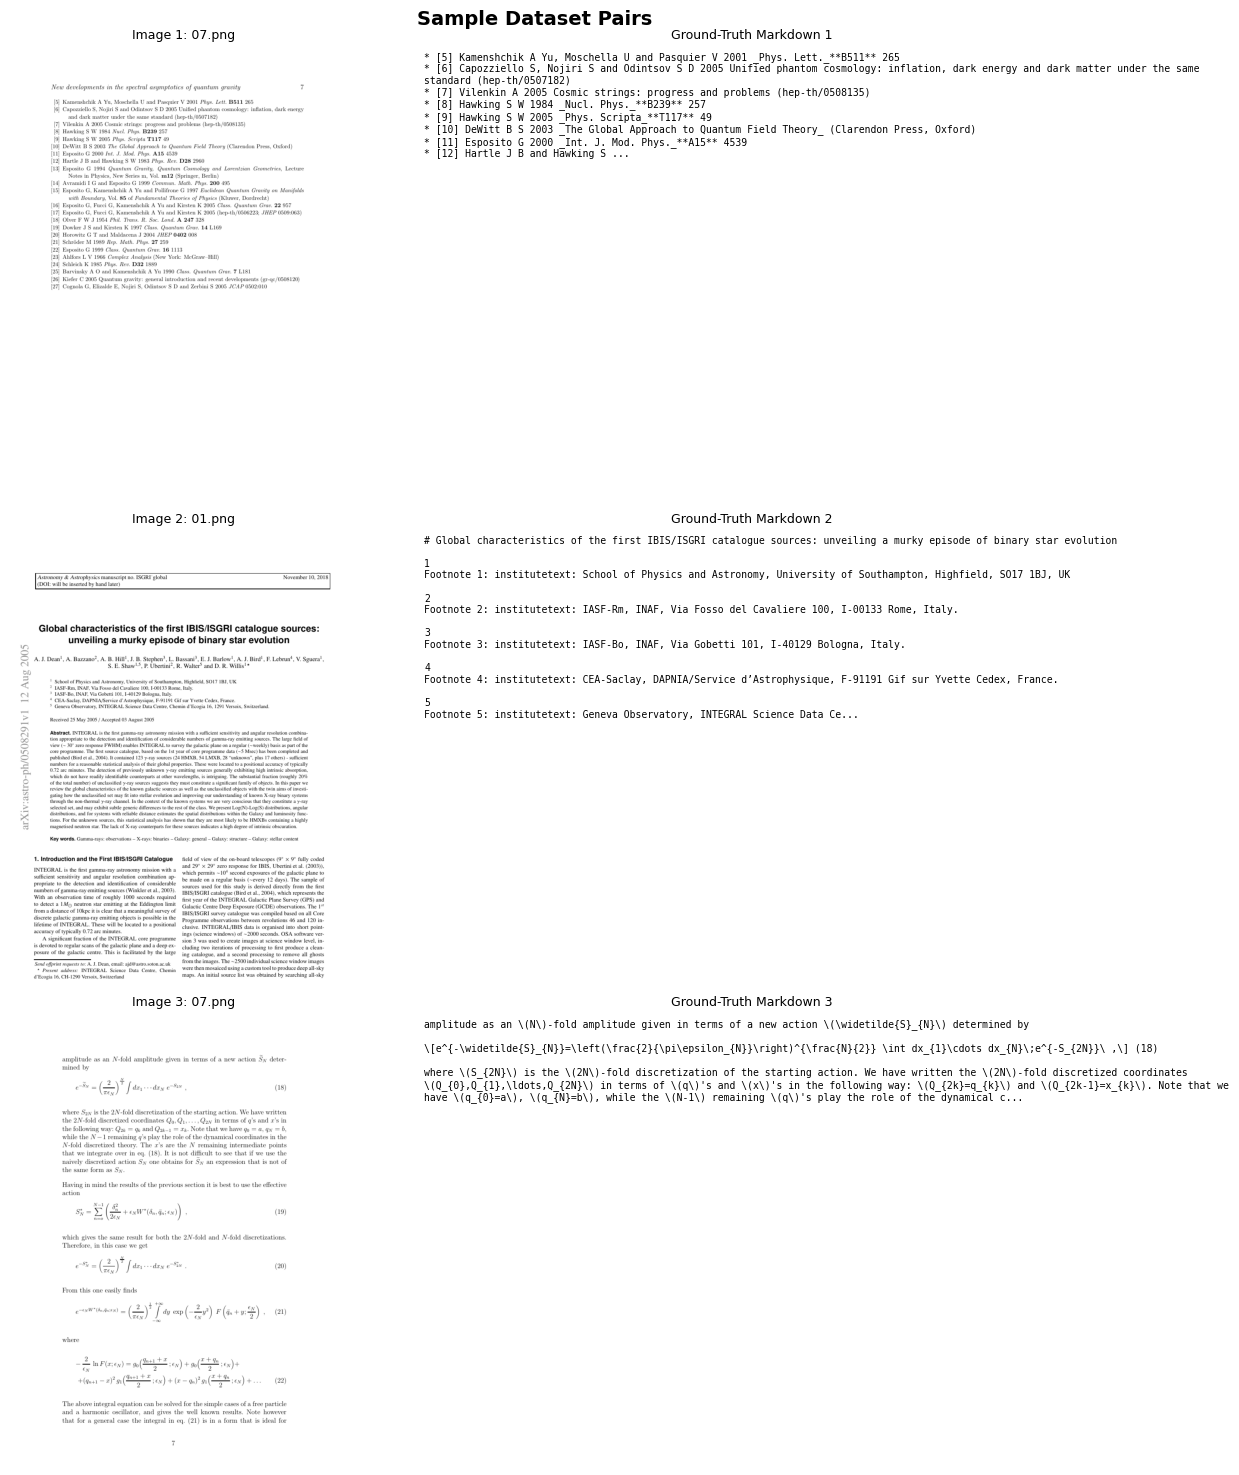

In [9]:
# ── visualise a few samples ───────────────────────────────────
def read_markdown(md_path_or_text: str) -> str:
    """Read markdown either from a file path or return inline text."""
    if os.path.exists(md_path_or_text):
        return Path(md_path_or_text).read_text(encoding='utf-8', errors='replace').strip()
    return md_path_or_text.strip()

def show_sample_pairs(pairs, n=3, title='Sample Dataset Pairs'):
    n = min(n, len(pairs))
    fig, axes = plt.subplots(n, 2, figsize=(14, 5 * n))
    if n == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i, (img_p, md_p) in enumerate(pairs[:n]):
        img = Image.open(img_p).convert('RGB')
        axes[i][0].imshow(img)
        axes[i][0].set_title(f'Image {i+1}: {Path(img_p).name}', fontsize=9)
        axes[i][0].axis('off')
        md = read_markdown(md_p)
        axes[i][1].text(0.01, 0.99, md[:600] + ('...' if len(md) > 600 else ''),
                        transform=axes[i][1].transAxes,
                        fontsize=7, va='top', ha='left',
                        family='monospace', wrap=True)
        axes[i][1].set_title(f'Ground-Truth Markdown {i+1}', fontsize=9)
        axes[i][1].axis('off')
    plt.tight_layout()
    plt.savefig('/kaggle/working/dataset_samples.png', dpi=100, bbox_inches='tight')
    plt.show()

if raw_pairs:
    show_sample_pairs(raw_pairs, n=min(3, len(raw_pairs)))
else:
    print('Skipping visualization — no pairs loaded.')

In [10]:
INSTRUCTION = (
    'You are an expert document parser. '
    'Convert the document image into well-structured Markdown. '
    'Preserve all headings, paragraphs, lists, tables, equations, and formatting. '
    'Output ONLY the Markdown content, nothing else.'
)

def build_chatml_record(image_path: str, markdown_text: str) -> dict:
    """Convert one pair into a ChatML-style record for Qwen2-VL."""
    return {
        'image_path': image_path,
        'markdown'  : markdown_text,
        'messages'  : [
            {
                'role': 'user',
                'content': [
                    {'type': 'image', 'image': image_path},
                    {'type': 'text',  'text' : INSTRUCTION},
                ],
            },
            {
                'role'   : 'assistant',
                'content': markdown_text,
            },
        ],
    }

# ── build records ─────────────────────────────────────────────
records = []
for img_p, md_p in raw_pairs:
    md_text = read_markdown(md_p)
    if md_text:                         # skip empty targets
        records.append(build_chatml_record(img_p, md_text))

# Cap if requested
if CFG['max_samples'] and len(records) > CFG['max_samples']:
    records = records[:CFG['max_samples']]

print(f'Total records: {len(records)}')

# ── 80 / 20 split ─────────────────────────────────────────────
random.shuffle(records)
split_idx   = int(len(records) * CFG['train_ratio'])
train_recs  = records[:split_idx]
val_recs    = records[split_idx:]
print(f'Train: {len(train_recs)}  |  Validation: {len(val_recs)}')

# Save paths for reload after kernel restart
with open('/kaggle/working/train_recs.json', 'w') as f:
    json.dump(train_recs, f)
with open('/kaggle/working/val_recs.json', 'w') as f:
    json.dump(val_recs, f)
print(' Splits saved.')

Total records: 2999
Train: 2399  |  Validation: 600
 Splits saved.


Markdown word-count  min=1  max=1725  mean=456  median=412


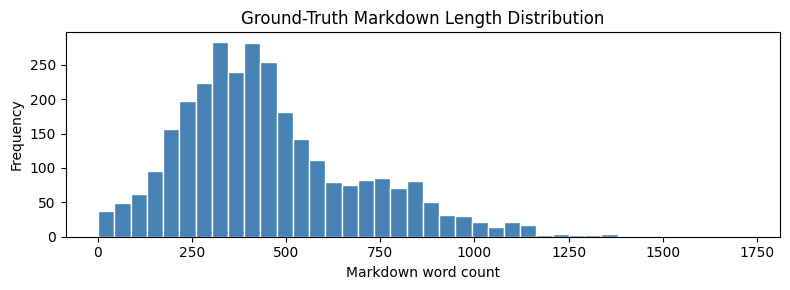

In [11]:
# ── Dataset lengths distribution ──────────────────────────────
md_lengths = [len(r['markdown'].split()) for r in records]
print(f'Markdown word-count  min={min(md_lengths)}  max={max(md_lengths)}  mean={np.mean(md_lengths):.0f}  median={np.median(md_lengths):.0f}')
plt.figure(figsize=(8, 3))
plt.hist(md_lengths, bins=40, color='steelblue', edgecolor='white')
plt.xlabel('Markdown word count')
plt.ylabel('Frequency')
plt.title('Ground-Truth Markdown Length Distribution')
plt.tight_layout()
plt.savefig('/kaggle/working/length_distribution.png', dpi=100)
plt.show()

In [12]:
free_memory()
mem_stats('before load')

# ── 4-bit quantisation config ─────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_use_double_quant = True,
    bnb_4bit_quant_type       = 'nf4',
    bnb_4bit_compute_dtype    = torch.float16,  # T4 safe
)

# ── Processor ─────────────────────────────────────────────────
print('Loading processor …')
processor = AutoProcessor.from_pretrained(
    CFG['model_name'],
    max_pixels=CFG['max_pixels'],
    min_pixels=CFG['min_pixels'],
    trust_remote_code=True,
)
processor.tokenizer.padding_side = 'right'
print('  Processor vocab size:', processor.tokenizer.vocab_size)

# ── Model ──────────────────────────────────────────────────────
print('Loading Qwen2-VL-2B in 4-bit …')
model = Qwen2VLForConditionalGeneration.from_pretrained(
    CFG['model_name'],
    quantization_config = bnb_config,
    device_map          = 'auto',   # spreads across both T4s automatically
    trust_remote_code   = True,
    torch_dtype         = torch.float16,
)
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
print('  Model parameters:', sum(p.numel() for p in model.parameters()) / 1e6, 'M')
mem_stats('after model load')

[before load] GPU mem  allocated=0.00 GB  reserved=0.00 GB
Loading processor …


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

  Model parameters: 1222.275584 M
[after model load] GPU mem  allocated=0.23 GB  reserved=0.53 GB


In [13]:
# ── LoRA configuration ────────────────────────────────────────
# Target modules: language model attention + MLP layers
lora_config = LoraConfig(
    r             = CFG['lora_r'],
    lora_alpha    = CFG['lora_alpha'],
    lora_dropout  = CFG['lora_dropout'],
    bias          = 'none',
    task_type     = TaskType.CAUSAL_LM,
    target_modules = [
        'q_proj', 'k_proj', 'v_proj', 'o_proj',
        'gate_proj', 'up_proj', 'down_proj',
    ],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
mem_stats('after LoRA wrap')

trainable params: 18,464,768 || all params: 2,227,450,368 || trainable%: 0.8290
[after LoRA wrap] GPU mem  allocated=0.23 GB  reserved=0.53 GB


In [14]:

BASE_MODEL_ID  = 'Qwen/Qwen2-VL-2B-Instruct'
ADAPTER_DIR    = '/kaggle/input/models/mahamismail/qlora-finetuning/pytorch/default/1'

IMG_SIZE   = 512
MAX_PIXELS = 512 * 512
MIN_PIXELS = 256 * 256
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

gc.collect()
torch.cuda.empty_cache()

bnb_config = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_use_double_quant = True,
    bnb_4bit_quant_type       = 'nf4',
    bnb_4bit_compute_dtype    = torch.float16,   # T4 safe
)

# ── Load base model ────────────────────────────────────────────
print('Loading base model in 4-bit …')
base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    BASE_MODEL_ID,
    quantization_config = bnb_config,
    device_map          = 'auto',       # spreads across both T4s
    torch_dtype         = torch.float16,
    trust_remote_code   = True,
)
print('   Base model loaded.')

# ── Attach LoRA adapters ───────────────────────────────────────
print('Attaching LoRA adapters …')
inf_model = PeftModel.from_pretrained(
    base_model,
    ADAPTER_DIR,
    is_trainable = False,               # inference only
)
inf_model.eval()
print('   Adapters attached.')

# ── Load processor (tokenizer + image processor) ───────────────
# adapter dir has: tokenizer.json, tokenizer_config.json,
#                  processor_config.json, chat_template.jinja
print('Loading processor …')
inf_processor = AutoProcessor.from_pretrained(
    ADAPTER_DIR,                        # loads all 4 files from adapter dir
    trust_remote_code = True,
    max_pixels        = MAX_PIXELS,
    min_pixels        = MIN_PIXELS,
)
inf_processor.tokenizer.padding_side = 'right'
print('   Processor loaded.')

# ── Sanity check ───────────────────────────────────────────────
alloc    = torch.cuda.memory_allocated() / 1e9
reserved = torch.cuda.memory_reserved()  / 1e9
print(f'\nGPU memory  allocated={alloc:.2f} GB  reserved={reserved:.2f} GB')
print(f'Vocab size : {inf_processor.tokenizer.vocab_size}')
print(f'Device map : {inf_model.hf_device_map}')
print('\n Model ready for inference.')

Loading base model in 4-bit …


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

   Base model loaded.
Attaching LoRA adapters …
   Adapters attached.
Loading processor …
   Processor loaded.

GPU memory  allocated=1.20 GB  reserved=1.69 GB
Vocab size : 151643
Device map : {'model.visual': 0, 'model.language_model.embed_tokens': 0, 'lm_head': 0, 'model.language_model.layers.0': 0, 'model.language_model.layers.1': 0, 'model.language_model.layers.2': 0, 'model.language_model.layers.3': 0, 'model.language_model.layers.4': 0, 'model.language_model.layers.5': 1, 'model.language_model.layers.6': 1, 'model.language_model.layers.7': 1, 'model.language_model.layers.8': 1, 'model.language_model.layers.9': 1, 'model.language_model.layers.10': 1, 'model.language_model.layers.11': 1, 'model.language_model.layers.12': 1, 'model.language_model.layers.13': 1, 'model.language_model.layers.14': 1, 'model.language_model.layers.15': 1, 'model.language_model.layers.16': 1, 'model.language_model.layers.17': 1, 'model.language_model.layers.18': 1, 'model.language_model.layers.19': 1, 'mo

In [11]:
class DocumentMarkdownDataset(Dataset):
    def __init__(self, records, processor, max_seq_len=1024, img_size=512):
        self.records     = records
        self.processor   = processor
        self.max_seq_len = max_seq_len
        self.img_size    = img_size

    def __len__(self):
        return len(self.records)

    def _resize(self, img: Image.Image) -> Image.Image:
        w, h = img.size
        scale = self.img_size / max(w, h)
        if scale < 1.0:
            img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
        return img

    def __getitem__(self, idx):
        rec = self.records[idx]
        try:
            img = Image.open(rec['image_path']).convert('RGB')
            img = self._resize(img)
        except Exception as e:
            # Return a blank image on read error to avoid crashing
            img = Image.new('RGB', (self.img_size, self.img_size), color='white')

        messages = rec['messages']

        # Build text with chat template
        text = self.processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )

        # Process image + text together
        inputs = self.processor(
            text        = [text],
            images      = [img],
            return_tensors = 'pt',
            padding     = True,
            truncation  = True,
            max_length  = self.max_seq_len,
        )

        # Squeeze batch dimension
        item = {k: v.squeeze(0) for k, v in inputs.items()}

        # Labels = input_ids; mask padding tokens with -100
        labels = item['input_ids'].clone()
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        # Mask the user/instruction part — only train on assistant response
        # Find the assistant token start
        assistant_token = self.processor.tokenizer.encode('<|im_start|>assistant', add_special_tokens=False)
        input_ids_list  = item['input_ids'].tolist()
        for start_pos in range(len(input_ids_list) - len(assistant_token)):
            if input_ids_list[start_pos:start_pos + len(assistant_token)] == assistant_token:
                labels[:start_pos + len(assistant_token)] = -100
                break

        item['labels'] = labels
        return item


def collate_fn(batch):
    """Pad all tensors in the batch to same length."""
    from torch.nn.utils.rnn import pad_sequence

    keys = batch[0].keys()
    collated = {}
    for k in keys:
        tensors = [item[k] for item in batch]
        if k == 'labels':
            collated[k] = pad_sequence(tensors, batch_first=True, padding_value=-100)
        elif k == 'attention_mask':
            collated[k] = pad_sequence(tensors, batch_first=True, padding_value=0)
        elif tensors[0].dim() == 0:
            collated[k] = torch.stack(tensors)
        else:
            try:
                collated[k] = pad_sequence(tensors, batch_first=True, padding_value=0)
            except Exception:
                collated[k] = tensors  # fallback: keep as list
    return collated

# Build datasets
train_dataset = DocumentMarkdownDataset(train_recs, processor, CFG['max_seq_len'], CFG['img_size'])
val_dataset   = DocumentMarkdownDataset(val_recs,   processor, CFG['max_seq_len'], CFG['img_size'])
print(f'Train samples: {len(train_dataset)}  |  Val samples: {len(val_dataset)}')

# Quick sanity check
sample = train_dataset[0]
print('Sanity check keys:', list(sample.keys()))
print('input_ids shape:', sample['input_ids'].shape)

Train samples: 2399  |  Val samples: 600
Sanity check keys: ['input_ids', 'attention_mask', 'pixel_values', 'image_grid_thw', 'labels']
input_ids shape: torch.Size([974])


In [12]:
# Detect whether to resume
resume_from = find_latest_checkpoint(CFG['output_dir'])
if resume_from:
    print(f'  Resuming from: {resume_from}')
else:
    print('  Starting training from scratch.')

total_steps = math.ceil(len(train_dataset) / (CFG['batch_size'] * CFG['grad_accum'])) * CFG['epochs']
warmup_steps = max(1, total_steps // 10)
print(f'Total optimiser steps: {total_steps}  |  Warmup steps: {warmup_steps}')

training_args = TrainingArguments(
    output_dir                  = CFG['output_dir'],
    num_train_epochs            = CFG['epochs'],
    per_device_train_batch_size = CFG['batch_size'],
    per_device_eval_batch_size  = CFG['batch_size'],
    gradient_accumulation_steps = CFG['grad_accum'],
    learning_rate               = CFG['lr'],
    lr_scheduler_type           = 'cosine',
    warmup_steps                = warmup_steps,
    fp16                        = CFG['fp16'],
    bf16                        = CFG['bf16'],
    logging_steps               = 10,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    save_total_limit            = 3,
    load_best_model_at_end      = True,
    metric_for_best_model       = 'eval_loss',
    greater_is_better           = False,
    dataloader_num_workers      = 2,
    dataloader_pin_memory       = True,
    remove_unused_columns       = False,
    report_to                   = 'none',
    seed                        = CFG['seed'],
    ddp_find_unused_parameters  = False,
    gradient_checkpointing      = True,
    # IMPORTANT for 4-bit + gradient checkpointing
    optim                       = 'paged_adamw_8bit',
    max_grad_norm               = 1.0,
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    data_collator   = collate_fn,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print('Trainer ready.')

  Starting training from scratch.
Total optimiser steps: 1200  |  Warmup steps: 120
Trainer ready.


In [13]:
# ── TRAINING ──────────────────────────────────────────────────
print(f' Starting/Resuming training …  [{datetime.now():%H:%M:%S}]')
mem_stats('pre-train')

train_result = trainer.train(resume_from_checkpoint=resume_from)

# Save meta after successful training
save_checkpoint_meta(
    epoch      = CFG['epochs'],
    step       = train_result.global_step,
    train_loss = train_result.training_loss,
)

print('\n Training complete!')
print(f'   Global step : {train_result.global_step}')
print(f'   Training loss: {train_result.training_loss:.4f}')
mem_stats('post-train')

 Starting/Resuming training …  [20:07:31]
[pre-train] GPU mem  allocated=0.23 GB  reserved=0.48 GB


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss
1,0.313590,0.409073
2,0.377216,0.406961


  Meta saved → /kaggle/working/training_log.json

 Training complete!
   Global step : 1200
   Training loss: 0.3772
[post-train] GPU mem  allocated=0.25 GB  reserved=2.12 GB


 Final model saved → /kaggle/working/final_model


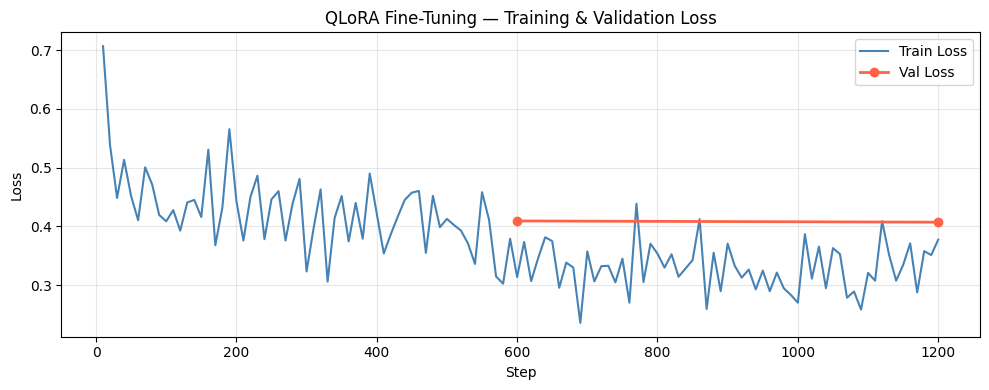

Log history saved.


In [14]:
# ── Save final adapter ────────────────────────────────────────
model.save_pretrained(CFG['final_model_dir'])
processor.save_pretrained(CFG['final_model_dir'])
print(f' Final model saved → {CFG["final_model_dir"]}')

# ── Plot training & eval loss ─────────────────────────────────
log_history = trainer.state.log_history

train_steps  = [e['step'] for e in log_history if 'loss' in e and 'eval_loss' not in e]
train_losses = [e['loss'] for e in log_history if 'loss' in e and 'eval_loss' not in e]
eval_steps   = [e['step'] for e in log_history if 'eval_loss' in e]
eval_losses  = [e['eval_loss'] for e in log_history if 'eval_loss' in e]

plt.figure(figsize=(10, 4))
plt.plot(train_steps, train_losses, label='Train Loss', color='steelblue', linewidth=1.5)
if eval_losses:
    plt.plot(eval_steps, eval_losses, 'o-', label='Val Loss', color='tomato', linewidth=2)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('QLoRA Fine-Tuning — Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/loss_curve.png', dpi=120)
plt.show()

# Save log history JSON
with open('/kaggle/working/log_history.json', 'w') as f:
    json.dump(log_history, f, indent=2)
print('Log history saved.')

In [15]:
# ── Reload best model for inference ──────────────────────────
# (safe to run even after kernel restart: loads from final_model_dir)
free_memory()

print('Loading inference model …')
inf_bnb = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_use_double_quant = True,
    bnb_4bit_quant_type       = 'nf4',
    bnb_4bit_compute_dtype    = torch.float16,
)
base_model_inf = Qwen2VLForConditionalGeneration.from_pretrained(
    CFG['model_name'],
    quantization_config = inf_bnb,
    device_map          = 'auto',
    torch_dtype         = torch.float16,
    trust_remote_code   = True,
)
inf_model = PeftModel.from_pretrained(base_model_inf, CFG['final_model_dir'])
inf_model.eval()

inf_processor = AutoProcessor.from_pretrained(
    CFG['final_model_dir'],
    trust_remote_code=True,
    max_pixels=CFG['max_pixels'],
    min_pixels=CFG['min_pixels'],
)
print('Inference model ready.')
mem_stats('after inf load')

Loading inference model …


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Inference model ready.
[after inf load] GPU mem  allocated=1.19 GB  reserved=1.64 GB


In [15]:
def generate_markdown(image_path_or_pil, model, processor, max_new_tokens=512, img_size=512):
    """Generate Markdown from a document image."""
    if isinstance(image_path_or_pil, str):
        img = Image.open(image_path_or_pil).convert('RGB')
    else:
        img = image_path_or_pil.convert('RGB')

    # Resize
    w, h = img.size
    scale = img_size / max(w, h)
    if scale < 1.0:
        img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)

    messages = [
        {
            'role': 'user',
            'content': [
                {'type': 'image', 'image': img},
                {'type': 'text',  'text' : INSTRUCTION},
            ],
        }
    ]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text        = [text],
        images      = image_inputs,
        videos      = video_inputs,
        return_tensors = 'pt',
        padding     = True,
    ).to(DEVICE)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens = max_new_tokens,
            do_sample      = False,
            temperature    = 1.0,
            repetition_penalty = 1.1,
        )

    # Decode only newly generated tokens
    generated_ids = output_ids[:, inputs['input_ids'].shape[1]:]
    result = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return result.strip()

print('generate_markdown() defined.')

generate_markdown() defined.


In [20]:
# =========================
# SAVE FINAL MODEL (LATEST)
# =========================

print("Saving final model...")

trainer.model.save_pretrained(CFG['final_model_dir'])
processor.save_pretrained(CFG['final_model_dir'])

print("Model saved to:", CFG['final_model_dir'])

Saving final model...
Model saved to: /kaggle/working/final_model


In [21]:
import shutil

zip_path = "/kaggle/working/final_model.zip"
folder_path = "/kaggle/working/final_model"

shutil.make_archive(zip_path.replace(".zip", ""), 'zip', folder_path)

print("Zipped successfully:", zip_path)

Zipped successfully: /kaggle/working/final_model.zip


In [16]:
print('Generating Markdown for validation samples …')
results = []

val_recs=val_recs[:20]

with torch.inference_mode():
    for i, rec in enumerate(val_recs):
        gen_md = generate_markdown(
            rec['image_path'],
            inf_model,
            inf_processor,
            max_new_tokens=256,
            img_size=CFG['img_size']
        )

        results.append({
            'image_path': rec['image_path'],
            'ground_truth': rec['markdown'],
            'generated': gen_md,
        })

        if (i + 1) % 5 == 0 or i == 0:
            print(f'  {i+1}/{len(val_recs)} done')

print('\nGeneration complete.')

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Generating Markdown for validation samples …
  1/20 done
  5/20 done
  10/20 done
  15/20 done
  20/20 done

Generation complete.


In [17]:
# ── ROUGE metrics ─────────────────────────────────────────────
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

r1_list, r2_list, rL_list = [], [], []
for r in results:
    scores = scorer.score(r['ground_truth'], r['generated'])
    r1_list.append(scores['rouge1'].fmeasure)
    r2_list.append(scores['rouge2'].fmeasure)
    rL_list.append(scores['rougeL'].fmeasure)

print(f'ROUGE-1  : {np.mean(r1_list):.4f}')
print(f'ROUGE-2  : {np.mean(r2_list):.4f}')
print(f'ROUGE-L  : {np.mean(rL_list):.4f}')

metrics_df = pd.DataFrame({
    'Metric': ['ROUGE-1', 'ROUGE-2', 'ROUGE-L'],
    'Score' : [np.mean(r1_list), np.mean(r2_list), np.mean(rL_list)],
})
metrics_df.to_csv('/kaggle/working/rouge_metrics.csv', index=False)
metrics_df

ROUGE-1  : 0.4501
ROUGE-2  : 0.3960
ROUGE-L  : 0.4207


,Metric,Score
0,ROUGE-1,0.450144
1,ROUGE-2,0.396015
2,ROUGE-L,0.420728


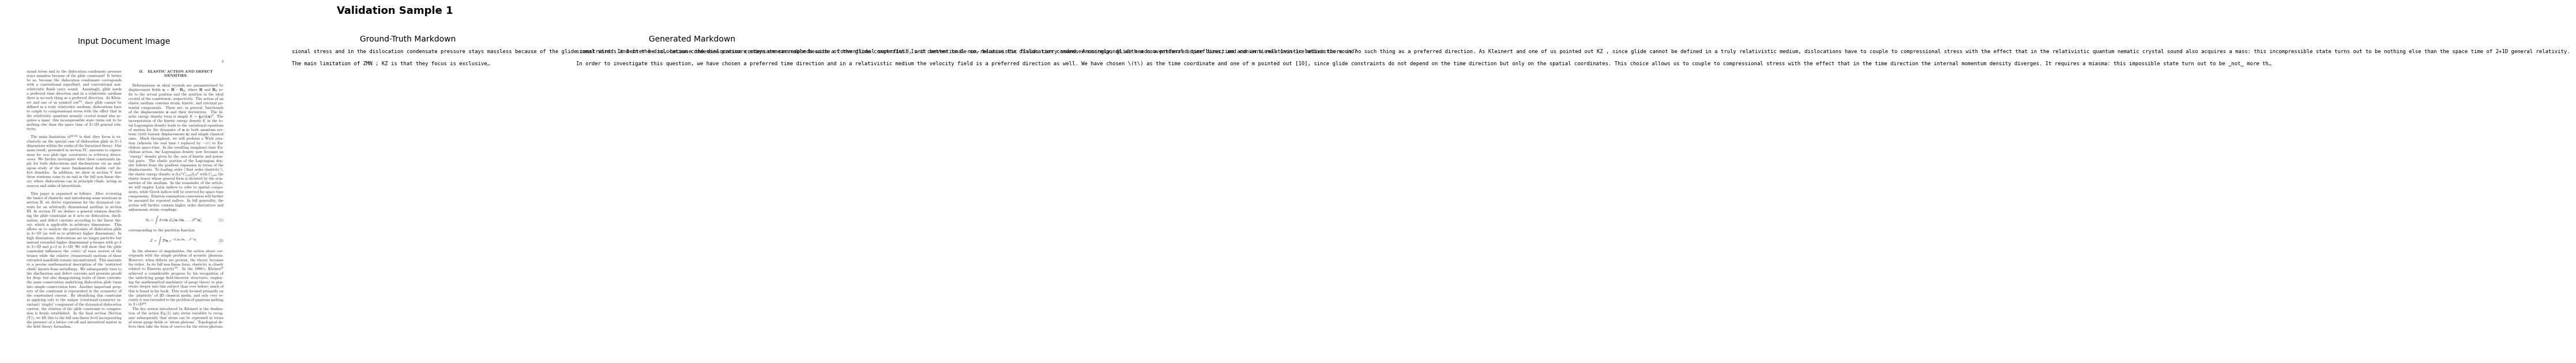

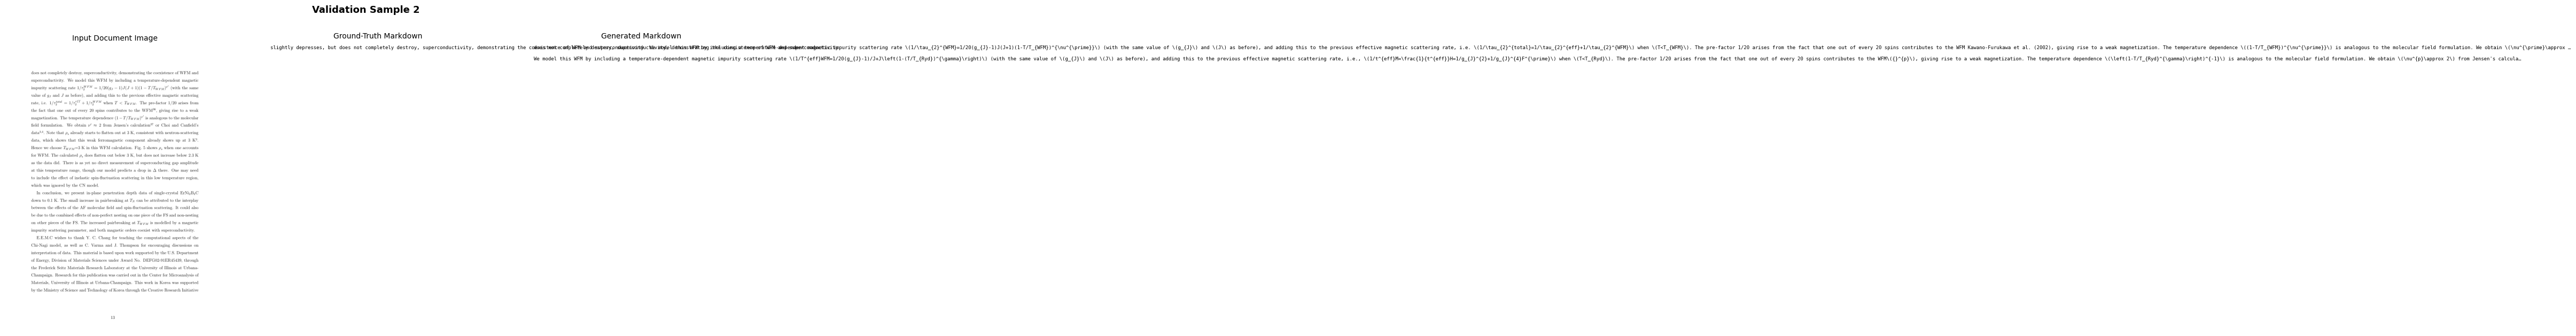

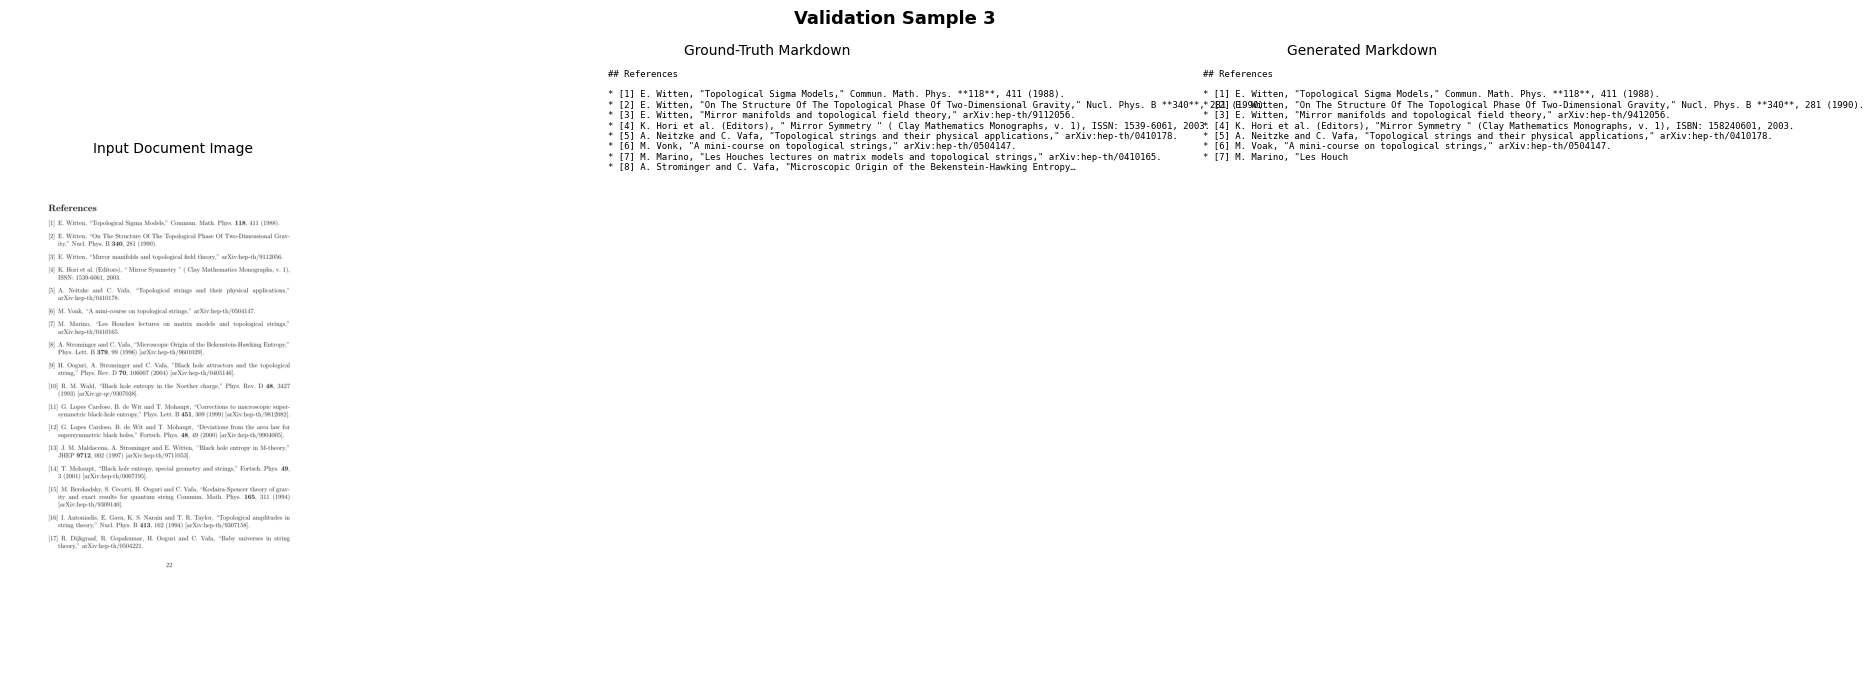

In [28]:
def visualize_result(result_dict, title='Prediction vs Ground Truth', save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # Column 1: image
    img = Image.open(result_dict['image_path']).convert('RGB')
    axes[0].imshow(img)
    axes[0].set_title('Input Document Image', fontsize=10)
    axes[0].axis('off')

    # Column 2: ground truth
    gt = result_dict['ground_truth']
    axes[1].text(0.01, 0.99, gt[:800] + ('…' if len(gt) > 800 else ''),
                 transform=axes[1].transAxes, fontsize=6.5, va='top', family='monospace')
    axes[1].set_title('Ground-Truth Markdown', fontsize=10)
    axes[1].axis('off')

    # Column 3: generated
    gen = result_dict['generated']
    axes[2].text(0.01, 0.99, gen[:800] + ('…' if len(gen) > 800 else ''),
                 transform=axes[2].transAxes, fontsize=6.5, va='top', family='monospace')
    axes[2].set_title('Generated Markdown', fontsize=10)
    axes[2].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=110, bbox_inches='tight')
    plt.show()
    plt.close('all')

# Show first 3 validation results
for idx, res in enumerate(results[:3]):
    visualize_result(res,
        title=f'Validation Sample {idx+1}',
        save_path=f'/kaggle/working/val_pred_{idx+1}.png')

In [31]:
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

def visualize_result_clean(result_dict, title='Result'):
    
    print(f"\n===== {title} =====\n")

    # 🔹 1. Show image (BIG)
    img = Image.open(result_dict['image_path']).convert('RGB')
    plt.figure(figsize=(6, 10))   # tall, not wide
    plt.imshow(img)
    plt.axis('off')
    plt.title("Input Image")
    plt.show()
    plt.close()

    # 🔹 2. Ground truth
    display(Markdown("### Ground Truth"))
    display(Markdown(f"```\n{result_dict['ground_truth'][:1500]}\n```"))

    # 🔹 3. Generated
    display(Markdown("### Generated"))
    display(Markdown(f"```\n{result_dict['generated'][:1500]}\n```"))

=== 3 TRAINING IMAGES ===

===== Train Image 1 =====



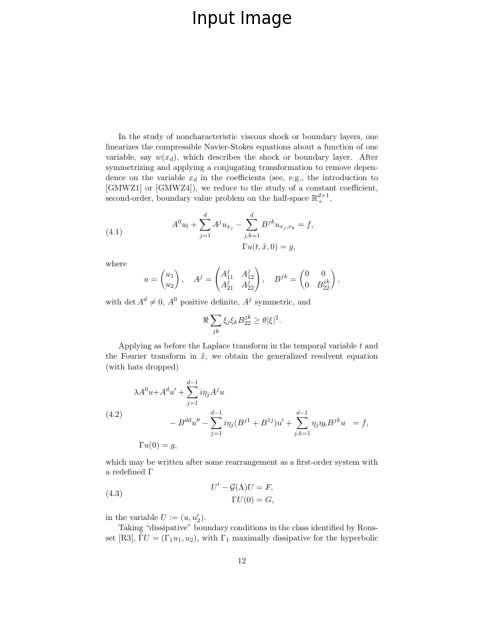

### Ground Truth

```
In the study of noncharacteristic viscous shock or boundary layers, one linearizes the compressible Navier-Stokes equations about a function of one variable, say \(w(x_{d})\), which describes the shock or boundary layer. After symmetrizing and applying a conjugating transformation to remove dependence on the variable \(x_{d}\) in the coefficients (see, e.g., the introduction to [GMWZ1] or [GMWZ4]), we reduce to the study of a constant coefficient, second-order, boundary value problem on the half-space \(\mathbb{R}^{d+1}_{+}\),

(4.1) \[A^{0}u_{t}+\sum_{j=1}^{d}A^{j}u_{x_{j}}-\sum_{j,k=1}^{d}B^{jk}u_ {x_{j},x_{k}} =f,\] \[\Gamma u(t,\tilde{x},0)=g,\]

where

\[u=\begin{pmatrix}u_{1}\\ u_{2}\end{pmatrix},\quad A^{j}=\begin{pmatrix}A^{j}_{11}&A^{j}_{12}\\ A^{j}_{21}&A^{j}_{22}\\ \end{pmatrix},\quad B^{jk}=\begin{pmatrix}0&0\\ 0&B^{jk}_{22}\\ \end{pmatrix},\]

with \(\det A^{d}\neq 0\), \(A^{0}\) positive definite, \(A^{j}\) symmetric, and

\[\Re\sum_{jk}\xi_{j}\xi_{k}B^{jk}_{22}\geq\theta|\xi|^{2}.\]

Applying as before the Laplace transform in the temporal variable \(t\) and the Fourier transform in \(\tilde{x}\), we obtain the generalized resolvent equation (with hats dropped)

(4.2) \[\lambda A^{0}u+ A^{d}u^{\prime}+\sum_{j=1}^{d-1}i\eta_{j}A^{j}u\] \[\quad-B^{dd}u^{\prime\prime}-\sum_{j=1}^{d-1}i\eta_{j}(B^{j1}+B^{ 1j})u^{\prime}+\sum_{j,k=1}^{d-1}\eta_{j}\eta_{k}B^{jk}u =f,\] \[\Gamma u(0) =g,\]

which may be written after some rearrangement as a first-order system with a r
```

### Generated

```
In the study of noncharacteristic viscous shock or boundary layers, one linearizes the compressible Navier-Stokes equations about a function of one variable, say \(u(x_{j})\), which describes the shock or boundary layer. After symmetrizing and applying a conjugating transformation to remove dependence on the variable \(x\) in the coefficients (see, e.g., the introduction to [KMWZ1] or [GMWZ2]), we reduce to the study of a constant coefficient, second-order, boundary value problem on the half-space \(\mathbb{R}^{d}_{+}\).

(4.1) \[A^{\prime\prime}u+\sum_{j=1}^{d}A^{\prime}u_{x_{j}}-\sum_{j=0,j\neq i }^{d}B^{\prime}u_{x_{i}x_{j}}=f,\] \[\Gamma(u,t,\bar{x},\bar{t})=g,\]

where

\[u=\left(\begin{array}[]{c}u_{1}\\ u_{2}\end{array}\right),~{}A^{\prime}=\left(\begin{array}[]{cc}A_{11}&A_{12}\\ A_{21}&A_{22}\end{array}\right),~{}B^{\prime}=\left(\begin{array}[]{c}0\\ 0&B_{22}^{-1}\end{array}\right)\]

with det \(A^{\prime}\neq 0\), \(A^{\prime}\) positive definite, \(A^{\prime}\) symmetric, and

\[\forall\sum_{j=1}^{d}B_{22}^{-1}B_{22}^{\prime}\leq g\|x\|^{2}.\]

Applying as before the Laplace transform in the temporal variable \(t\) and the Fourier transform in \(\hat{x}\), we obtain the generalized resolvent equation (with hats dropped)

\[\lambda A^{\prime\prime}u+A^{\prime}u_{x}+\sum_{j=1}^{d}\eta_{jy}Au_{x} =f,\] (4.2) \[-Bu^{\prime\prime}u_{x}-\sum_{j=0,j\neq i}
```


===== Train Image 2 =====



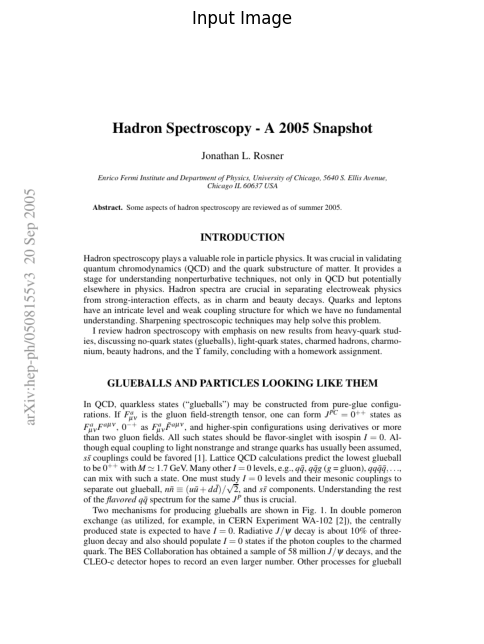

### Ground Truth

```
# Hadron Spectroscopy - A 2005 Snapshot

Jonathan L. Rosner

###### Abstract

Some aspects of hadron spectroscopy are reviewed as of summer 2005.

Keywords: Hadron spectroscopy; heavy quarks : PACS numbers: 14.20.Lq, 14.40.Cs, 14.40.Gx, 14.40.Lb

## 1 INTRODUCTION

Hadron spectroscopy plays a valuable role in particle physics. It was crucial in validating quantum chromodynamics (QCD) and the quark substructure of matter. It provides a stage for understanding nonperturbative techniques, not only in QCD but potentially elsewhere in physics. Hadron spectra are crucial in separating electroweak physics from strong-interaction effects, as in charm and beauty decays. Quarks and leptons have an intricate level and weak coupling structure for which we have no fundamental understanding. Sharpening spectroscopic techniques may help solve this problem.

I review hadron spectroscopy with emphasis on new results from heavy-quark studies, discussing no-quark states (glueballs), light-quark states, charmed hadrons, charmonium, beauty hadrons, and the \(\Upsilon\) family, concluding with a homework assignment.

## 2 GLUEBALLS AND PARTICLES LOOKING LIKE THEM

In QCD, quarkless states ("glueballs") may be constructed from pure-glue configurations. If \(F^{a}_{\mu\nu}\) is the gluon field-strength tensor, one can form \(J^{PC}=0^{++}\) states as \(F^{a}_{\mu\nu}F^{a\mu\nu}\), \(0^{-+}\) as \(F^{a}_{\mu\nu}\tilde{F}^{a\mu\nu}\), and higher-spin configurations using derivatives or more than two g
```

### Generated

```
# Hadron Spectroscopy - A 2005 Snapshot

Jonathan L. Rosner

Enrico Fermi Institute and Department of Physics, University of Chicago, 5640 S. Ellis Avenue, Chicago IL 60637 USA

###### Abstract

Some aspects of hadron spectroscopy are reviewed as of summer 2005.

## I Introduction

Hadron spectroscopy plays a valuable role in particle physics. It was crucial in validating quantum chromodynamics (QCD) and the quark substructure of matter. It provides a stage for understanding nonperturbative techniques, not only in QCD but potentially elsewhere in physics. Hadron spectra are crucial in separating electroweak physics from strong-interaction effects, as in charm and beauty decays. Quarks and leptons have an intrinsic level and weak coupling structure for which we have no fundamental understanding. Sharpening spectroscopic techniques may help solve this problem.

I review hadron spectroscopy with emphasis on new results from heavy-quark studies, discussing no-quark states (glueballs), light-quark states, charmed hadrons, charmium, beauty hadrons, and the T family, concluding with a homework assignment.

## II Glueballs and particles looking like them

In QCD, quarkless states ("glueballs") may be constructed from pure-glu configuration. If \(F_{\pi}^{a}\) is the gluon field-strength tensor, one can form \({}^{P}F^{\mu\nu}=0^{-+}\) states as \(F_{\pi}^{a}{ }^{P}F^{\mu\nu}_{\alpha\beta}\), and higher-spin configurations using derivatives or more than two gluon fields. All such stat
```


===== Train Image 3 =====



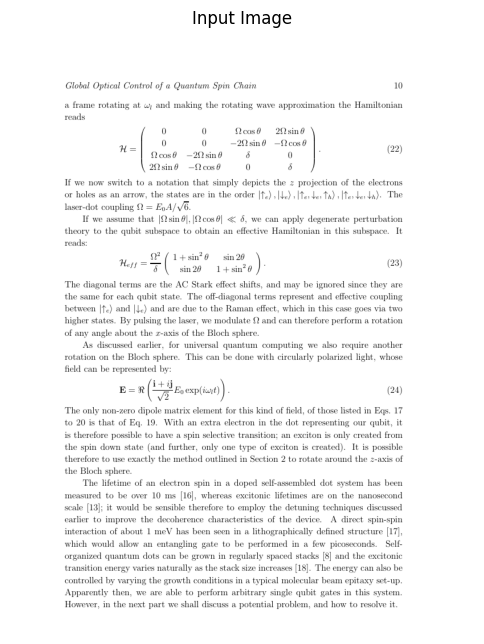

### Ground Truth

```
a frame rotating at \(\omega_{l}\) and making the rotating wave approximation the Hamiltonian reads

\[{\cal H}=\left(\begin{array}[]{cccc}0&0&\Omega\cos\theta&2\Omega\sin\theta\\ 0&0&-2\Omega\sin\theta&-\Omega\cos\theta\\ \Omega\cos\theta&-2\Omega\sin\theta&\delta&0\\ 2\Omega\sin\theta&-\Omega\cos\theta&0&\delta\\ \end{array}\right).\] (22)

If we now switch to a notation that simply depicts the \(z\) projection of the electrons or holes as an arrow, the states are in the order \(\left|\uparrow_{e}\right\rangle,\left|\downarrow_{e}\right\rangle,\left| \uparrow_{e},\downarrow_{e},\uparrow_{h}\right\rangle,\left|\uparrow_{e}, \downarrow_{e},\downarrow_{h}\right\rangle\). The laser-dot coupling \(\Omega=E_{0}A/\sqrt{6}\).

If we assume that \(|\Omega\sin\theta|,|\Omega\cos\theta|\ll\delta\), we can apply degenerate perturbation theory to the qubit subspace to obtain an effective Hamiltonian in this subspace. It reads:

\[{\cal H}_{eff}=\frac{\Omega^{2}}{\delta}\left(\begin{array}[]{cc}1+\sin^{2} \theta&\sin 2\theta\\ \sin 2\theta&1+\sin^{2}\theta\end{array}\right).\] (23)

The diagonal terms are the AC Stark effect shifts, and may be ignored since they are the same for each qubit state. The off-diagonal terms represent and effective coupling between \(\left|\uparrow_{e}\right\rangle\) and \(\left|\downarrow_{e}\right\rangle\) and are due to the Raman effect, which in this case goes via two higher states. By pulsing the laser, we modulate \(\Omega\) and can therefore perform a r
```

### Generated

```
a frame rotating at \(\omega_{1}\) and making the rotating wave approximation the Hamiltonian reads

\[{\cal H}=\left( \begin{array}[]{ccc}0&\Omega\cos\theta&2\Omega\sin\theta\\ 0&-\Omega\sin\theta&-\Omega\cos\theta\\ -2\Omega\sin\theta&\Omega\cos\theta&0\end{array}\right)\] (3)

If we now switch to a notation that simply depicts the \(z\) projection of the electrons or holes as an arrow, the states are in the order \(\{|z\rangle,\{|z_{+}\rangle,\{|z_{-}\rangle,i_{z},|t_{z}\rangle,\{|i_{z},i_{x},i _{y}\rangle\}}\). The laser-dot coupling \({\cal O}=E_{L}{\bf\hat{v}}/\sqrt{2}\).

If we assume that \(\Omega|\sin\theta|\), \(\Omega|\cos\theta|\ll\delta\), we can apply degenerate perturbation theory to the qubit subspace to obtain an effective Hamiltonian in this subspace. It reads:

\[{\cal H}_{eff}={\frac{\Omega^{2}}{4}}\left( \begin{array}[]{ccc}\Omega&1+\sin^{2}\theta&\sin 2\theta\\ 1+\sin^{2}\theta&\sin 2\theta&1+\sin^{2}\theta\\ \sin 2\theta&1+\sin^{2}\theta&\Omega\end{array}\right).\] (4)

The diagonal terms are the AC Stark effect shifts, and may be ignored since they are the same for each qubit state. The off-diagonal terms represent effective coupling between \(\{|z\rangle\) and \(\{|z_{\pm}\rangle\) and are due to the Raman effect, which in this case goes via two higher states. By pulsing the laser, we modulate \({\cal O}\) and can therefore perform a rotation of any angle about the z-axis of the Bloch sphere.

As discussed earlier, for universal quantum computing we a
```


=== 3 UNSEEN IMAGES ===

===== Unseen Image 1 =====



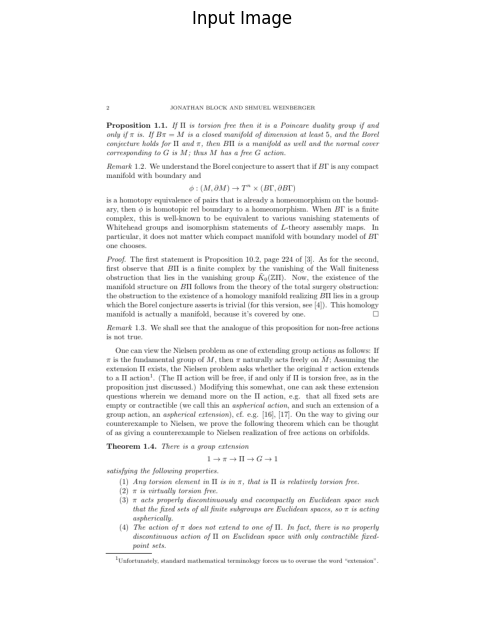

### Ground Truth

```
**Proposition 1.1****.**: _If \(\Pi\) is torsion free then it is a Poincare duality group if and only if \(\pi\) is. If \(B\pi=M\) is a closed manifold of dimension at least \(5\), and the Borel conjecture holds for \(\Pi\) and \(\pi\), then \(B\Pi\) is a manifold as well and the normal cover corresponding to \(G\) is \(M\); thus \(M\) has a free \(G\) action._

_Remark 1.2__._: We understand the Borel conjecture to assert that if \(B\Gamma\) is any compact manifold with boundary and

\[\phi:(M,\partial M)\to T^{n}\times(B\Gamma,\partial B\Gamma)\]

is a homotopy equivalence of pairs that is already a homeomorphism on the boundary, then \(\phi\) is homotopic rel boundary to a homeomorphism. When \(B\Gamma\) is a finite complex, this is well-known to be equivalent to various vanishing statements of Whitehead groups and isomorphism statements of \(L\)-theory assembly maps. In particular, it does not matter which compact manifold with boundary model of \(B\Gamma\) one chooses.

Proof.: The first statement is Proposition 10.2, page 224 of [3]. As for the second, first observe that \(B\Pi\) is a finite complex by the vanishing of the Wall finiteness obstruction that lies in the vanishing group \(\tilde{K}_{0}(\mathbb{Z}\Pi)\). Now, the existence of the manifold structure on \(B\Pi\) follows from the theory of the total surgery obstruction: the obstruction to the existence of a homology manifold realizing \(B\Pi\) lies in a group which the Borel conjecture asserts is trivial (for t
```

### Generated

```
**Proposition 1.1****.**: _If \(\Pi\) is torsion free then it is a Poincare duality group if and only if \(\pi\). If \(B\Pi=M\) is a closed manifold of dimension at least \(5\), and the Borel conjecture holds for \(\pi\), then \(B\Pi\) is RR in a manifold \(M\) and the normal covering corresponds to \(G:M\); thus \(M\) has a free \(G\) action._

**Remark 1.2****.**: We understand the Borel-conjecture to assert that if \(B\Pi\) is any compact manifold with boundary and

\[\phi:(M,\partial M)\to T^{*}(B\Pi;\partial T\Pi)\]

is a homotopy equivalence of pairs that is locally a homology map on the boundary, then \(\phi\) is homotopic rel boundary to a homeomorphism.

When \(B\Pi\) is a finite complex, this is well-known to be equivalent to various vanishing statements of Whitehead groups and homotopy statements of Lefschetz assembly maps. In particular, it does not matter which compact manifold with boundary model of \(B\Pi\) one chooses.

Proof.: The first statement is Proposition 10.2, page 224 of [3]. As for the second, first observe that \(RR\) is a finite complex by the vanishing of the Wall bimeridian obstruction that lies in the vanishing group \(K_{2}(RR)\). Now, the existence of the manifold structure on \(RR\) follows from the theory of the total surgery obstruction: the obstruction to the existence of a homology manifold resulting \(RR\) lies in a group which the Borel conjecture asserts is trivial (for this version, see [4]). This homology manifold is actually torsion
```


===== Unseen Image 2 =====



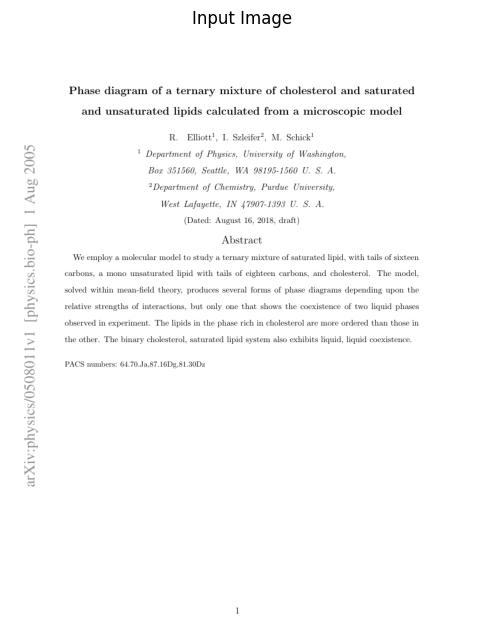

### Ground Truth

```
# Phase diagram of a ternary mixture of cholesterol and saturated and unsaturated lipids calculated from a microscopic model

R. Elliott\({}^{1}\), I. Szleifer\({}^{2}\), M. Schick\({}^{1}\)

\({}^{1}\) Department of Physics, University of Washington, Box 351560, Seattle, WA 98195-1560 U. S. A.

\({}^{2}\)Department of Chemistry, Purdue University, West Lafayette, IN 47907-1393 U. S. A.

(October 11, 2023, draft)

###### Abstract

We employ a molecular model to study a ternary mixture of saturated lipid, with tails of sixteen carbons, a mono unsaturated lipid with tails of eighteen carbons, and cholesterol. The model, solved within mean-field theory, produces several forms of phase diagrams depending upon the relative strengths of interactions, but only one that shows the coexistence of two liquid phases observed in experiment. The lipids in the phase rich in cholesterol are more ordered than those in the other. The binary cholesterol, saturated lipid system also exhibits liquid, liquid coexistence.

pacs: 64.70.Ja,87.16Dg,81.30Dz
```

### Generated

```
# Phase diagram of a ternary mixture of cholesterol and saturated and unsaturated lipids calculated from a microscopic model

R. Elliott\({}^{1}\), I. Suleider\({}^{2}\), M. Schick\({}^{3}\)

\({}^{1}\)Department of Physics, University of Washington,

Box 351560, Seattle, WA 98195-1560 U. S. A.

\({}^{2}\)Department of Chemistry, Purdue University,

West Lafayette, IN 47907-1393 U. S. A.

(October 12, 2023)

###### Abstract

We employ a molecular model to study a ternary mixture of saturated lipid, with tails of sixteen carbons, a mono unsaturated lipid with tails of eighteen carbons, and cholesterol. The model, solved within mean-field theory, produces several forms of phase diagrams depending upon the relative strengths of interactions, but only one that shows the coexistence of two liquid phases observed in experiment. The lipids in the phase rich in cholesterol are more ordered than those in the other. The binary cholesterol, saturated lipid system also exhibits liquid, liquid coexistence.

pacs: 64.70.Ja,87.16Dy,81.30Bz

## I
```


===== Unseen Image 3 =====



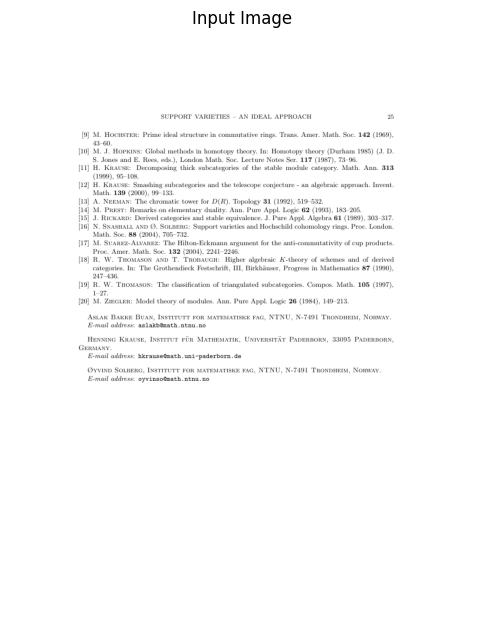

### Ground Truth

```
* [9]M. Hochster: Prime ideal structure in commutative rings. Trans. Amer. Math. Soc. **142** (1969), 43-60.
* [10]M. J. Hopkins: Global methods in homotopy theory. In: Homotopy theory (Durham 1985) (J. D. S. Jones and E. Rees, eds.), London Math. Soc. Lecture Notes Ser. **117** (1987), 73-96.
* [11]H. Krause: Decomposing thick subcategories of the stable module category. Math. Ann. **313** (1999), 95-108.
* [12]H. Krause: Smashing subcategories and the telescope conjecture - an algebraic approach. Invent. Math. **139** (2000), 99-133.
* [13]A. Neeman: The chromatic tower for \(D(R)\). Topology **31** (1992), 519-532.
* [14]M. Prest: Remarks on elementary duality. Ann. Pure Appl. Logic **62** (1993), 183-205.
* [15]J. Rickard: Derived categories and stable equivalence. J. Pure Appl. Algebra **61** (1989), 303-317.
* [16]N. Snashall and O. Solberg: Support varieties and Hochschild cohomology rings. Proc. London. Math. Soc. **88** (2004), 705-732.
* [17]M. Suarez-Alvarez: The Hilton-Eckmann argument for the anti-commutativity of cup products. Proc. Amer. Math. Soc. **132** (2004), 2241-2246.
* [18]R. W. Thomason and T. Trobaugh: Higher algebraic \(K\)-theory of schemes and of derived categories. In: The Grothendieck Festschrift, III, Birkhauser, Progress in Mathematics **87** (1990), 247-436.
* [19]R. W. Thomason: The classification of triangulated subcategories. Compos. Math. **105** (1997), 1-27.
* [20]M. Ziegler: Model theory of modules. Ann. Pure Appl. Logic **26** (1984), 
```

### Generated

```
* [9] M. Rochester: Prime ideal structure in commutative rings. Trans. Amer. Math. Soc. **142** (1969), 45-98.
* [10] M. J. Hopkins: Global methods in homotopy theory. In: Homotopy theory (Durham 1985) (J. D. S. Jones and E. Rees, eds.), London Math. Soc. Lecture Notes Ser. **117** (1987), 73-96.
* [11] R. Kauers: Decomposing thick subcategories of the stable module category. Math. Ann. **313** (1998), 95-108.
* [12] R. Kauers: Merging subcategories and the telescope conjecture - an algebraic approach. Invent. Math. **139** (2000), 99-133.
* [13] A. Neeman: The chromatic tower for \(D(R)\). Topology **31** (1992), 519-522.
* [14] M. Pervt: Remarks on elementary duality. Ann. Pure Appl. Logic **62** (1993), 183-205.
* [15] H. Reiten: Lectures on modules. Algebra Colloquium XXXIII (1988), 308-317. MR 90h:16005; MR 91m:16005; MR 92b:16005.
* [16] N. Samelson and O. Solberg: Support varieties and Hochschild cohomology ring. Proc. London Math. Soc. **68** (2003), 755-772.
* [17] M. Suarez-Avilez: The Hilton-Erkanius argument for the anti-commutativity of cup products. Proc. Amer. Math. Soc., **133** (2005), 2241-2246.
* [18] R. W. Thomason and T. Thorpe: Higher algebraic \(K\)-theory of schemes and of derived
```


Testing complete.


In [32]:
print('=== 3 TRAINING IMAGES ===')

train_test_recs = random.sample(train_recs, min(3, len(train_recs)))
train_test_results = []

for i, rec in enumerate(train_test_recs):
    gen = generate_markdown(
        rec['image_path'], inf_model, inf_processor,
        max_new_tokens=512, img_size=CFG['img_size']
    )

    r = {
        'image_path': rec['image_path'],
        'ground_truth': rec['markdown'],
        'generated': gen
    }

    train_test_results.append(r)

    visualize_result_clean(r, title=f'Train Image {i+1}')

    free_memory()


print('\n=== 3 UNSEEN IMAGES ===')

unseen_recs = val_recs[-3:] if len(val_recs) >= 3 else val_recs

for i, rec in enumerate(unseen_recs):
    gen = generate_markdown(
        rec['image_path'], inf_model, inf_processor,
        max_new_tokens=512, img_size=CFG['img_size']
    )

    r = {
        'image_path': rec['image_path'],
        'ground_truth': rec['markdown'],
        'generated': gen
    }

    visualize_result_clean(r, title=f'Unseen Image {i+1}')

    free_memory()

print('\nTesting complete.')

In [21]:


inf_bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16,
)

Loading zero-shot model for comparison …


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

 Zero-shot model ready.


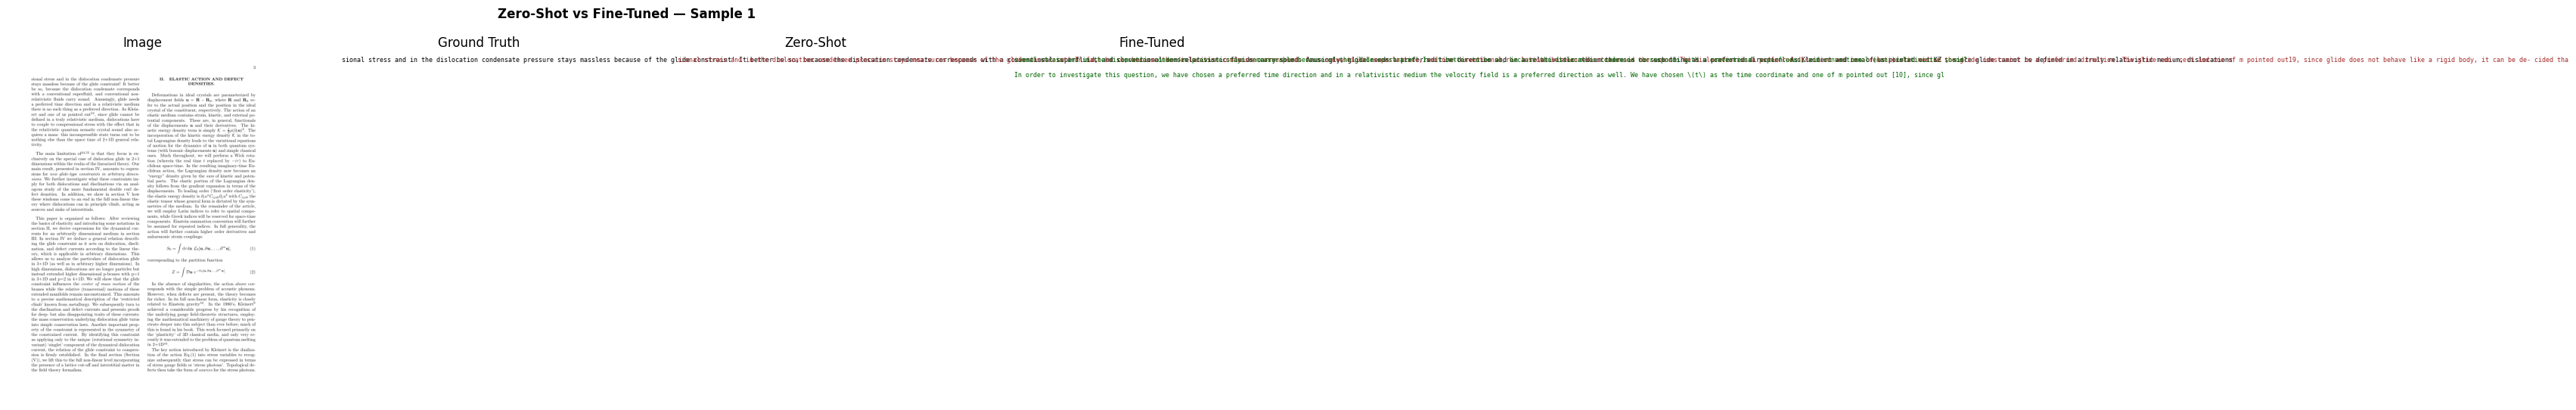

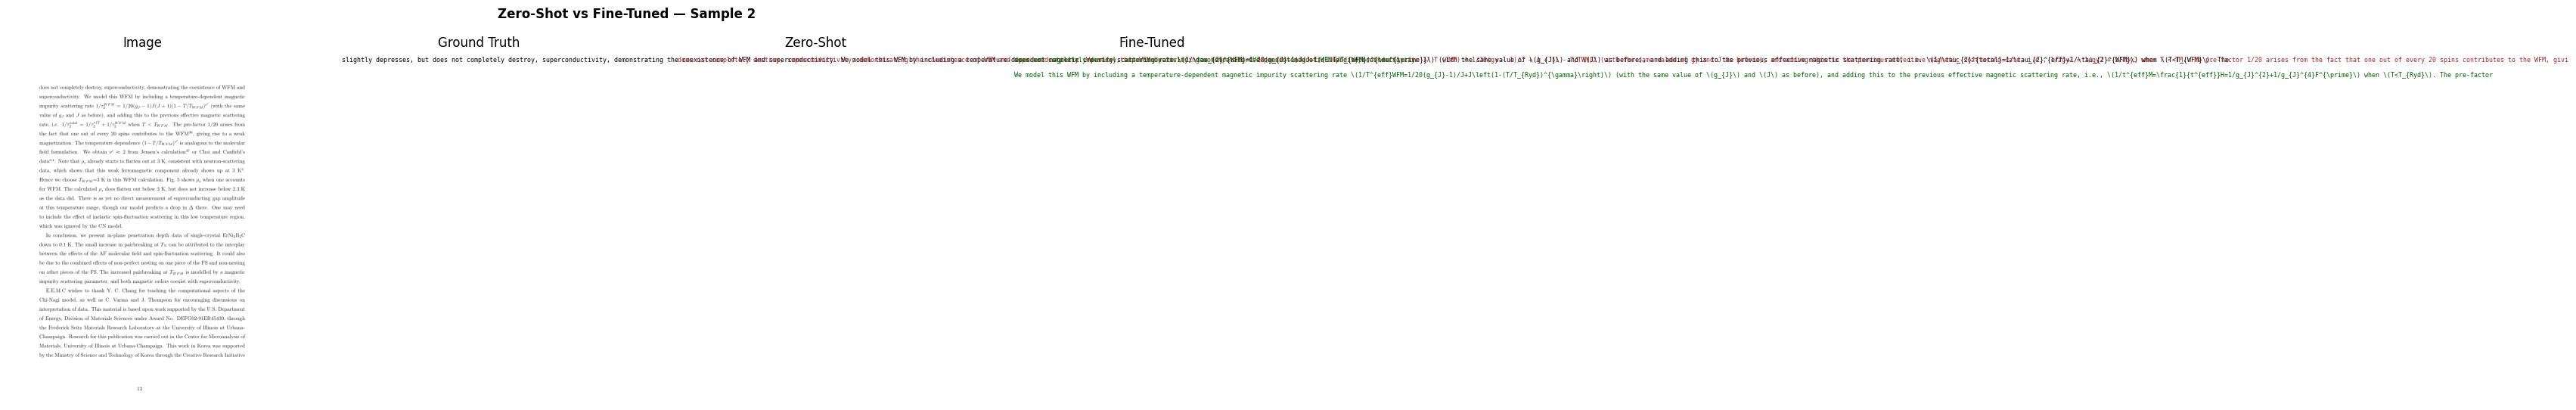

Comparison done.


In [22]:
print('Loading zero-shot model for comparison …')
free_memory()

zs_model = Qwen2VLForConditionalGeneration.from_pretrained(
    CFG['model_name'],
    quantization_config = inf_bnb,
    device_map          = 'auto',
    torch_dtype         = torch.float16,
    trust_remote_code   = True,
)
zs_model.eval()
print(' Zero-shot model ready.')

# Compare on 2 samples
compare_recs = val_recs[:2]
for i, rec in enumerate(compare_recs):
    zs_md = generate_markdown(rec['image_path'], zs_model, inf_processor,
                              max_new_tokens=400, img_size=CFG['img_size'])
    ft_md = generate_markdown(rec['image_path'], inf_model, inf_processor,
                              max_new_tokens=400, img_size=CFG['img_size'])

    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    img = Image.open(rec['image_path']).convert('RGB')
    axes[0].imshow(img); axes[0].set_title('Image'); axes[0].axis('off')

    gt = rec['markdown']
    axes[1].text(0.01, 0.99, gt[:500], transform=axes[1].transAxes, fontsize=6, va='top', family='monospace')
    axes[1].set_title('Ground Truth'); axes[1].axis('off')

    axes[2].text(0.01, 0.99, zs_md[:500], transform=axes[2].transAxes, fontsize=6, va='top', family='monospace', color='brown')
    axes[2].set_title('Zero-Shot'); axes[2].axis('off')

    axes[3].text(0.01, 0.99, ft_md[:500], transform=axes[3].transAxes, fontsize=6, va='top', family='monospace', color='darkgreen')
    axes[3].set_title('Fine-Tuned'); axes[3].axis('off')

    plt.suptitle(f'Zero-Shot vs Fine-Tuned — Sample {i+1}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/compare_zs_ft_{i+1}.png', dpi=110, bbox_inches='tight')
    plt.show()
    free_memory()

del zs_model
free_memory()
print('Comparison done.')

Loading zero-shot model for comparison …


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Zero-shot model ready.

===== Sample 1 =====



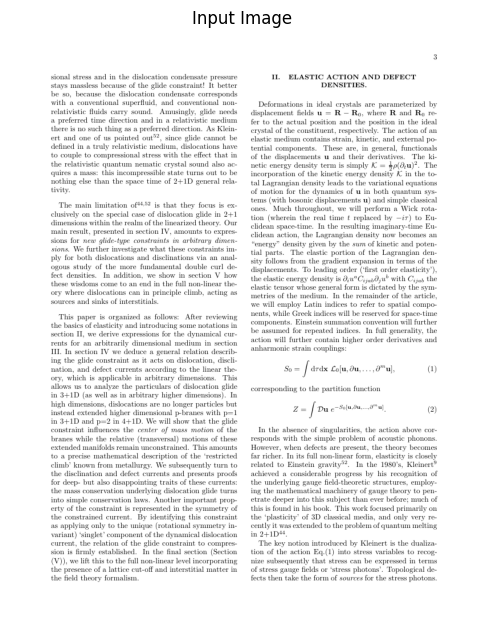

### Ground Truth

```
sional stress and in the dislocation condensate pressure stays massless because of the glide constraint! It better be so, because the dislocation condensate corresponds with a conventional superfluid, and conventional non-relativistic fluids carry sound. Amusingly, glide needs a preferred time direction and in a relativistic medium there is no such thing as a preferred direction. As Kleinert and one of us pointed out KZ , since glide cannot be defined in a truly relativistic medium, dislocations have to couple to compressional stress with the effect that in the relativistic quantum nematic crystal sound also acquires a mass: this incompressible state turns out to be nothing else than the space time of 2+1D general relativity.

The main limitation of ZMN ; KZ is that they focus is exclusively on the special case of dislocation glide in 2+1 dimensions within the realm of the linearized theory. Our main result, presented in section IV, amounts to expressions for _new glide-type constraints in arbitrary dimensions_. We further investigate what these constraints imply for both dislocations and disclinations via an analogous study of the more fundamental double curl defect densities. In addition, we show in section V how these wisdoms come to an end in the full non-linear theory where dislocations can in principle climb, acting as sources and sinks of interstitials.

This paper is organized as follows: After reviewing the basics of elasticity and introducing some notations in secti
```

### Zero-Shot Output

```
sional stress and in the dislocation condensee pressure stays mea.sures because of the glide constraint! In fact be so, because the dislocation condensee corresponds to a conventional superlattice, and non-conventional re- lations between the strain and the sound. The dislocation is a preferred direction and in a relativistic medium the glide constraint is a preferred direction. The glide con- cert and one of m pointed out19, since glide does not behave like a rigid body, it can be de- cided that the dislocation must couple to compressional stress with the eflfet that in the dislocation itself. In this sense, the dislocation seems to require a tension. This incomparable state turn out to be more than the space time of 2D rela. tivity general de- tensity. The main limitation of42 is that they form ex- clusive relations between the dislocations and the dimensions within the realm of the linearized theory. Our method is based on section VII which expresse. nces for new glide-type constraints in arbitrary dimen- sions where we investigate whether these constraints can be ap- ply for both dislocations and dilatations via anal. ogy. We have shown that the fundamental double curl de- fect densities. In addition, we show in section V how these come to an end in the full non-linear theo- phy where dislocations can occur in principle, acting as sources and sinks of interstitials. The dislocation constraint is defined as follows: After reviewing the basics of elasticity and introducing 
```

### Fine-Tuned Output

```
sional stress and in the dislocation condensee pressure stays unmeasurable because of the glide constraint! Is it better to be so, because the dislocation condensee corresponds with a conventional superfluous, and conventional (non-)relativistic sound?

In order to investigate this question, we have chosen a preferred time direction and in a relativistic medium the velocity field is a preferred direction as well. We have chosen \(t\) as the time coordinate and one of m pointed out [10], since glide constraints do not depend on the time direction but only on the spatial coordinates. This choice allows us to couple to compressional stress with the effect that in the time direction the internal momentum density diverges. It requires a miasma: this impossible state turn out to be _not_ more than the space time of 2+1D general relativity.

The main limitation of eq.(3) is that they form an _exclusion principle_ case of non-relativistic dynamics within dimensions within the realm of the linearized theory. Our main goal here is in section IV to develop expressions for _new glide-type constraints in arbitrary dimensions_, which will investigate whether they can be applied for both dislocations and dilatations via an analysis of the corresponding fundamental double curl defect densities. In addition, we show in section V how these ideas come to an end in the full non-linear theory where dislocations can in principle act, causing sources and sinks of intensities.

Our results are summa
```


===== Sample 2 =====



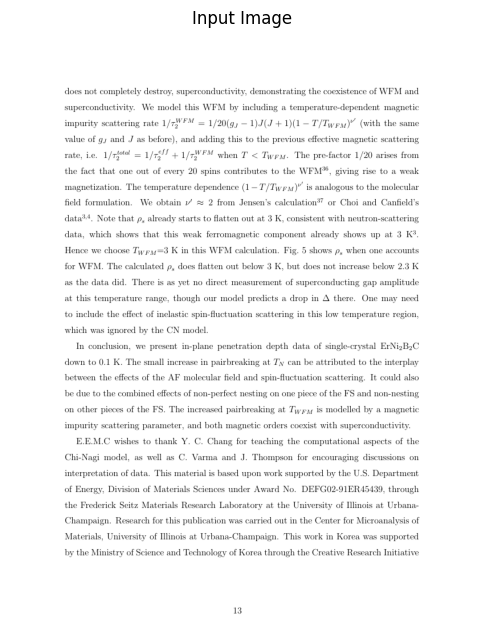

### Ground Truth

```
slightly depresses, but does not completely destroy, superconductivity, demonstrating the coexistence of WFM and superconductivity. We model this WFM by including a temperature-dependent magnetic impurity scattering rate \(1/\tau_{2}^{WFM}=1/20(g_{J}-1)J(J+1)(1-T/T_{WFM})^{\nu^{\prime}}\) (with the same value of \(g_{J}\) and \(J\) as before), and adding this to the previous effective magnetic scattering rate, i.e. \(1/\tau_{2}^{total}=1/\tau_{2}^{eff}+1/\tau_{2}^{WFM}\) when \(T<T_{WFM}\). The pre-factor 1/20 arises from the fact that one out of every 20 spins contributes to the WFM Kawano-Furukawa et al. (2002), giving rise to a weak magnetization. The temperature dependence \((1-T/T_{WFM})^{\nu^{\prime}}\) is analogous to the molecular field formulation. We obtain \(\nu^{\prime}\approx 2\) from Jensen's calculation Jensen (2002) or Choi and Canfield's data Choi et al. (2001); Canfield et al. (1996). Note that \(\rho_{s}\) already starts to flatten out at 3 K, consistent with neutron-scattering data, which shows that this weak ferromagnetic component already shows up at 3 K Choi et al. (2001). Hence we choose \(T_{WFM}\)=3 K in this WFM calculation. Fig. 5 shows \(\rho_{s}\) when one accounts for WFM. The calculated \(\rho_{s}\) does flatten out below 3 K, but does not increase below 2.3 K as the data did. There is as yet no direct measurement of superconducting gap amplitude at this temperature range, though our model predicts a drop in \(\Delta\) there. One may need to in
```

### Zero-Shot Output

```
does not completely destroy, superconductivity, demonstrating the coexistence of WFM and superconductivity. We model this WFM by including a temperature-dependent magnetic impurity scattering rate 1/ T (TWM) = 1/20(gy - 1)/J + J + (1 - T/TWM)2 (with the same value of gy and J as before), and adding this to the previous effective magnetic scattering rate, i.e., 1/2gy2 = 1/gy2 + 1/4gyJ when T < TM. The pre-factor 1/20 arises from the fact that one out of every 20 spins contributes to the WFM, giving rise to a weak magnetization. The temperature dependence (1 - T/TWM)2 is analogous to the molecular field formulation. We obtain r2 ≈ 2 from Jensen's calculation[3] or Choi and Canfield's data[4]. Note that p0 already starts to flatten out at 3 K, consistent with neutron-scattering data, which shows that this weak ferromagnetic component already shows up at 3 K. Hence we choose TWM=3K in this WFM calculation. Fig. 5 shows p0 when one accounts for WFM. The calculated p0 does flatten out below 3 K, but does not increase below 2.3 K as the data did. There is as yet no direct measurement of superconducting gap amplitude at this temperature range, though our model predicts a drop in A there. One may need to include the effect of inelastic spin-fluctuation scattering in this low temperature region, which was ignored by the CN model. In conclusion, we present in-plane penetration depth data of single-crystal ErNi2B2C down to 0.1 K. The small increase in pairbreaking at Tc can be attributed
```

### Fine-Tuned Output

```
does not completely destroy, superconductivity, demonstrating the coexistence of WFM and superconductivity.

We model this WFM by including a temperature-dependent magnetic impurity scattering rate \(1/T^{eff}WFM=1/20(g_{J}-1)/J+J\left(1-(T/T_{Ryd})^{\gamma}\right)\) (with the same value of \(g_{J}\) and \(J\) as before), and adding this to the previous effective magnetic scattering rate, i.e., \(1/t^{eff}M=\frac{1}{t^{eff}}H=1/g_{J}^{2}+1/g_{J}^{4}F^{\prime}\) when \(T<T_{Ryd}\). The pre-factor 1/20 arises from the fact that one out of every 20 spins contributes to the WFM\({}^{p}\), giving rise to a weak magnetization. The temperature dependence \(\left(1-T/T_{Ryd}^{\gamma}\right)^{-1}\) is analogous to the molecular field formulation. We obtain \(\nu^{p}\approx 2\) from Jensen's calculation [37] or Choi and Canfield's data [48]. Note that \(\mu_{p}\) already starts to flatten out at 3 K, consistent with neutron-scattering data, which shows that this weak ferromagnetic component already shows up at 3 K. Hence we choose \(T_{Ryd}/k_{B}\approx 3\) in this WFM calculation. Fig. 5 shows \(\mu_{p}\) when one accounts for WFM. The calculated \(\mu_{p}\) does flatten out below 3 K, but does not increase below 2.3 K as the data did. There is as yet no direct measurement of superconducting gap amplitude at this temperature range, though our
```

Comparison done.


In [33]:
print('Loading zero-shot model for comparison …')
free_memory()

zs_model = Qwen2VLForConditionalGeneration.from_pretrained(
    CFG['model_name'],
    quantization_config = inf_bnb,
    device_map          = 'auto',
    torch_dtype         = torch.float16,
    trust_remote_code   = True,
)
zs_model.eval()
print('Zero-shot model ready.')




def visualize_comparison(rec, zs_md, ft_md, idx=1):
    print(f"\n===== Sample {idx} =====\n")

    # 🔹 Image (large & clean)
    img = Image.open(rec['image_path']).convert('RGB')
    plt.figure(figsize=(6, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Input Image")
    plt.show()
    plt.close()

    # 🔹 Ground Truth
    display(Markdown("### Ground Truth"))
    display(Markdown(f"```\n{rec['markdown'][:1500]}\n```"))

    # 🔹 Zero-shot output
    display(Markdown("### Zero-Shot Output"))
    display(Markdown(f"```\n{zs_md[:1500]}\n```"))

    # 🔹 Fine-tuned output
    display(Markdown("### Fine-Tuned Output"))
    display(Markdown(f"```\n{ft_md[:1500]}\n```"))


# Compare on 2 samples
compare_recs = val_recs[:2]

for i, rec in enumerate(compare_recs):
    zs_md = generate_markdown(
        rec['image_path'],
        zs_model,
        inf_processor,
        max_new_tokens=400,
        img_size=CFG['img_size']
    )

    ft_md = generate_markdown(
        rec['image_path'],
        inf_model,
        inf_processor,
        max_new_tokens=400,
        img_size=CFG['img_size']
    )

    visualize_comparison(rec, zs_md, ft_md, idx=i+1)
    free_memory()


del zs_model
free_memory()

print('Comparison done.')

In [24]:
print('='*60)
print(' VLM QLoRA FINE-TUNING — SUMMARY REPORT')
print('='*60)
print(f'Model         : {CFG["model_name"]}')
print(f'Dataset pairs : {len(records)}')
print(f'Train / Val   : {len(train_recs)} / {len(val_recs)}')
print(f'Epochs        : {CFG["epochs"]}')
print(f'Batch size    : {CFG["batch_size"]}  (grad accum {CFG["grad_accum"]})')
print(f'LoRA rank     : {CFG["lora_r"]}  alpha={CFG["lora_alpha"]}')
print(f'Learning rate : {CFG["lr"]}')
print(f'Image size    : {CFG["img_size"]}px')
print(f'Quantization  : 4-bit NF4')
print()

if 'train_result' in dir():
    print(f'Final train loss : {train_result.training_loss:.4f}')


print()
print('ROUGE Scores (Validation):')
print(f'  ROUGE-1  = {np.mean(r1_list):.4f}')
print(f'  ROUGE-2  = {np.mean(r2_list):.4f}')
print(f'  ROUGE-L  = {np.mean(rL_list):.4f}')

print()
print('Output files:')
for fp in sorted(Path('/kaggle/working').glob('*.png')) + sorted(Path('/kaggle/working').glob('*.json')) + sorted(Path('/kaggle/working').glob('*.csv')):
    size = fp.stat().st_size / 1024
    print(f'  {fp.name:<40}  {size:.1f} KB')
print('='*60)

 VLM QLoRA FINE-TUNING — SUMMARY REPORT
Model         : Qwen/Qwen2-VL-2B-Instruct
Dataset pairs : 2999
Train / Val   : 2399 / 20
Epochs        : 2
Batch size    : 1  (grad accum 4)
LoRA rank     : 16  alpha=32
Learning rate : 0.00015
Image size    : 512px
Quantization  : 4-bit NF4


ROUGE Scores (Validation):
  ROUGE-1  = 0.4501
  ROUGE-2  = 0.3960
  ROUGE-L  = 0.4207

Output files:
  compare_zs_ft_1.png                       295.0 KB
  compare_zs_ft_2.png                       204.9 KB
  dataset_samples.png                       417.8 KB
  length_distribution.png                   19.1 KB
  train_pred_1.png                          155.9 KB
  train_pred_2.png                          179.2 KB
  train_pred_3.png                          224.8 KB
  unseen_pred_1.png                         213.1 KB
  unseen_pred_2.png                         141.8 KB
  unseen_pred_3.png                         151.9 KB
  val_pred_1.png                            356.2 KB
  val_pred_2.png                

In [25]:
import gradio as gr

def _ensure_model():
    global inf_model, inf_processor
    try:
        _ = inf_model
    except NameError:
        print('Reloading model for Gradio …')
        _bnb = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type='nf4', bnb_4bit_compute_dtype=torch.float16,
        )
        _base = Qwen2VLForConditionalGeneration.from_pretrained(
            CFG['model_name'], quantization_config=_bnb,
            device_map='auto', torch_dtype=torch.float16, trust_remote_code=True,
        )
        inf_model = PeftModel.from_pretrained(_base, CFG['final_model_dir'])
        inf_model.eval()
        inf_processor = AutoProcessor.from_pretrained(
            CFG['final_model_dir'], trust_remote_code=True,
            max_pixels=CFG['max_pixels'], min_pixels=CFG['min_pixels'],
        )

_ensure_model()


def predict_markdown(image, max_tokens=512):
    if image is None:
        return '⚠️ Please upload an image.'
    try:
        pil_img = Image.fromarray(image).convert('RGB') if not isinstance(image, Image.Image) else image
        md = generate_markdown(pil_img, inf_model, inf_processor,
                               max_new_tokens=int(max_tokens), img_size=CFG['img_size'])
        return md
    except Exception as e:
        return f'Error: {e}'


with gr.Blocks(title='Document → Markdown Generator', theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 📄 Document to Markdown Generator
    **Model:** Qwen2-VL-2B-Instruct  •  **Fine-tuned with:** QLoRA on Nougat dataset  
    Upload a document image and get structured Markdown output.
    """)

    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(label='Upload Document Image', type='pil')
            max_tokens_slider = gr.Slider(128, 1024, value=512, step=64,
                                          label='Max Output Tokens')
            run_btn = gr.Button('🔄 Generate Markdown', variant='primary')

        with gr.Column(scale=1):
            md_output  = gr.Textbox(label='Generated Markdown (raw)',
                                    lines=20, max_lines=40, show_copy_button=True)
            md_preview = gr.Markdown(label='Rendered Preview')

    def on_click(img, max_tok):
        result = predict_markdown(img, max_tok)
        return result, result

    run_btn.click(fn=on_click,
                  inputs=[image_input, max_tokens_slider],
                  outputs=[md_output, md_preview])

    gr.Examples(
        examples=[[r['image_path']] for r in val_recs[:2]] if val_recs else [],
        inputs=image_input,
        label='Example Document Images',
    )

print('Launching Gradio app …')
demo.launch(share=True, debug=False)

Launching Gradio app …
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://e429d947b63b76ebf1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
